In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from true_graph import TrueGraph
from learner import FactorGraphLearner
from metrics import *
from random_graph import generate_random_graph, generate_random_tree

In [64]:
rng = np.random.default_rng(seed=311)
random_graph = generate_random_graph(n=10, alphabet_size=3, n_factors=8, rng=rng)

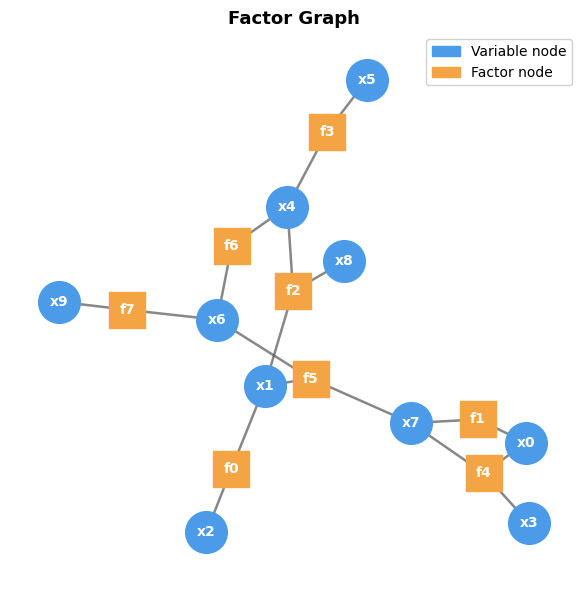

In [65]:
random_graph.display_graph(seed=388)
plt.show()

In [ ]:
def one_learner(graph, samples, K, hidden_dims=(16,16), max_factor_size=None, shared_mlp=False,
                epochs=100, lr=0.01, l_mask=0.1, l_weight=0.01, l_mlp=0.01, l_bp=0.001, schedule=True,
                seed=123, verbose=True):
    alph_size = graph.alphabet_sizes[0]
    n_vars = graph.n
    ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=456)

In [ ]:
def all_learners(graph, samples, reg_strengths, K, hidden_dims=(16,16), max_factor_size=None, shared_mlp=False,
                 epochs=100, lr=0.01, l_mlp=0.01, schedule=True, verbose=True):
    learners = {}
    alph_size = graph.alphabet_sizes[0]
    n_vars = graph.n
    for l_mask, l_weight, l_bp in reg_strengths:
        ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=456)
        lrn, diags = test_learner(graph, samples, K, hidden_dims, max_factor_size, shared_mlp, epochs, lr, 

In [ ]:
def test_learner(graph, samples, K, hidden_dims=(16,16), max_factor_size=None, shared_mlp=False, 
                 epochs=100, lr=1e-3, l_mask=0.1, l_weight=0.01, l_mlp=0.01, l_bp=0.01, schedule=False,
                 seed=123, verbose=True, plot=True):
    alph_size = graph.alphabet_sizes[0]
    n_vars = graph.n
    ng = IndependentMarginals(samples, alphabet_size=alph_size, alpha=1, seed=456)
    learner = FactorGraphLearner(n_vars=n_vars, alphabet_size=alph_size, K=K, noise_generator=ng, 
                                 hidden_dims=hidden_dims, max_factor_size=max_factor_size, shared_mlp=shared_mlp, seed=seed)
    ls, diags = learner.train(samples, n_epochs=epochs, lr=lr, 
                              lambda_mask=l_mask, lambda_weight=l_weight, lambda_mlp_l2=l_mlp, lambda_bp=l_bp, penalty_schedule=schedule,
                              log_every=10, verbose=verbose)
    if plot:
        plot_losses(ls)
        plot_diagnostics(diags)


In [13]:
help(generate_random_graph)

Help on function generate_random_graph in module random_graph:

generate_random_graph(n, alphabet_size, rng, n_factors=None, max_factor_size=3, strength=1.0)

